# PhyCV PAGE: directional edge detection with a bank of oriented phase kernels

**PAGE** (Phase-stretch Adaptive Gradient-field Extractor) is the oriented sibling of the Phase Stretch
Transform. Where PST uses one isotropic phase kernel, PAGE uses a **bank of directional phase kernels**
$\phi_k(\rho,\theta)=\phi_r(\rho)\,D_k(\theta)$: the same radial phase-stretch profile $\phi_r$ as PST,
multiplied by an **angular window** $D_k(\theta)$ centered on frequency orientation $\theta_k$. Each kernel
responds to edges of one orientation, so the transform returns not just *where* the edges are but *which
way they run* -- an orientation-encoded edge field, usually shown in HSV (hue = orientation, value =
strength).

It is the same all-pass dispersive-phase operator this project uses for time-stretch, now made
**anisotropic** in 2-D spatial frequency. Linear-algebra view: PAGE is a bank of linear FFT filters
followed by a per-pixel argmax over orientation. PhyCV is open-source; we build PAGE from the equations.

Kernel: $\phi_r(\rho)=S\big[W\rho\arctan(W\rho)-\tfrac12\ln(1+(W\rho)^2)\big]/\max(\cdot)$, and
$D_k(\theta)=e^{-\Delta\theta_k^2/2\sigma_\theta^2}+e^{-\Delta(\theta_k+\pi)^2/2\sigma_\theta^2}$ (symmetric
in $\theta$, so opposite frequencies pair up). Self-contained: NumPy, SciPy, Matplotlib.

In [1]:
import numpy as np, pandas as pd, sympy as sp
import matplotlib.pyplot as plt
from types import SimpleNamespace
from fractions import Fraction

# --- physical constants (CODATA 2018, SI) ------------------------------------
C = SimpleNamespace(
    C=299792458.0, H=6.62607015e-34, HBAR=6.62607015e-34/(2*np.pi), E=1.602176634e-19,
    K_B=1.380649e-23, N_A=6.02214076e23, EPS0=8.8541878128e-12, MU0=1.25663706212e-6,
    M_E=9.1093837015e-31, M_P=1.67262192369e-27, A0=5.29177210903e-11,
    RYDBERG_EV=13.605693122994, R_INF=10973731.568160, MU_B=9.2740100783e-24,
    ALPHA=7.2973525693e-3, EV=1.602176634e-19, NM=1e-9)
C.COULOMB_K = 1.0/(4*np.pi*C.EPS0)
C.table = lambda: pd.DataFrame(
    [("c",C.C,"m/s"),("h",C.H,"J s"),("hbar",C.HBAR,"J s"),("e",C.E,"C"),("k_B",C.K_B,"J/K"),
     ("N_A",C.N_A,"1/mol"),("eps0",C.EPS0,"F/m"),("m_e",C.M_E,"kg"),("m_p",C.M_P,"kg"),
     ("a0",C.A0,"m"),("Ry",C.RYDBERG_EV,"eV"),("mu_B",C.MU_B,"J/T"),("alpha",C.ALPHA,"1")],
    columns=["symbol","value_SI","unit"])

# --- dimensional analysis over the seven SI base quantities ------------------
_BASE = ("L","M","T","I","K","N","J")
class Dimension:
    __slots__=("e",)
    def __init__(s,**k): s.e={b:Fraction(k.get(b,0)) for b in _BASE}
    def __mul__(s,o): return Dimension(**{b:s.e[b]+o.e[b] for b in _BASE})
    def __truediv__(s,o): return Dimension(**{b:s.e[b]-o.e[b] for b in _BASE})
    def __pow__(s,p): p=Fraction(p); return Dimension(**{b:s.e[b]*p for b in _BASE})
    def __eq__(s,o): return isinstance(o,Dimension) and s.e==o.e
    def __hash__(s): return hash(tuple(s.e[b] for b in _BASE))
    @property
    def is_dimensionless(s): return all(v==0 for v in s.e.values())
    def __repr__(s):
        p=[f"{b}^{s.e[b]}" for b in _BASE if s.e[b]!=0]; return "dimensionless" if not p else " ".join(p)
class Quantity:
    __slots__=("value","dim")
    def __init__(s,v,d=None): s.value=float(v); s.dim=d if d is not None else Dimension()
    def __mul__(s,o): return Quantity(s.value*o.value,s.dim*o.dim) if isinstance(o,Quantity) else Quantity(s.value*o,s.dim)
    __rmul__=__mul__
    def __truediv__(s,o): return Quantity(s.value/o.value,s.dim/o.dim) if isinstance(o,Quantity) else Quantity(s.value/o,s.dim)
    def __pow__(s,p): return Quantity(s.value**float(p),s.dim**p)
    def __add__(s,o):
        if not isinstance(o,Quantity) or s.dim!=o.dim: raise ValueError("cannot add incompatible dimensions")
        return Quantity(s.value+o.value,s.dim)
    def __sub__(s,o):
        if not isinstance(o,Quantity) or s.dim!=o.dim: raise ValueError("cannot subtract incompatible dimensions")
        return Quantity(s.value-o.value,s.dim)
    def to_dimension(s,d):
        if s.dim!=d: raise ValueError(f"expected dimension {d}, found {s.dim}")
        return s
    def __repr__(s): return f"Quantity({s.value:g}, {s.dim})"
U = SimpleNamespace(Dimension=Dimension, Quantity=Quantity, DIMENSIONLESS=Dimension(),
                    LENGTH=Dimension(L=1), MASS=Dimension(M=1), TIME=Dimension(T=1),
                    CURRENT=Dimension(I=1), TEMPERATURE=Dimension(K=1), AMOUNT=Dimension(N=1))
U.VELOCITY=U.LENGTH/U.TIME; U.ACCELERATION=U.VELOCITY/U.TIME; U.FORCE=U.MASS*U.ACCELERATION
U.ENERGY=U.FORCE*U.LENGTH; U.POWER=U.ENERGY/U.TIME; U.CHARGE=U.CURRENT*U.TIME
U.VOLTAGE=U.ENERGY/U.CHARGE; U.FREQUENCY=U.DIMENSIONLESS/U.TIME; U.ACTION=U.ENERGY*U.TIME
U.WAVENUMBER=U.DIMENSIONLESS/U.LENGTH; U.E_FIELD=U.VOLTAGE/U.LENGTH

# --- linear-algebra helpers --------------------------------------------------
def _gram_schmidt(V):
    A=np.asarray(V,complex); n,k=A.shape; Q=np.zeros((n,k),complex)
    for j in range(k):
        v=A[:,j].copy()
        for i in range(j): v-=np.vdot(Q[:,i],v)*Q[:,i]
        nv=np.linalg.norm(v)
        if nv<1e-14: raise ValueError("vectors are linearly dependent")
        Q[:,j]=v/nv
    return Q
def _eigosystem(A):
    w,V=np.linalg.eigh(np.asarray(A)); idx=np.argsort(w.real); return w[idx].real, V[:,idx]
def _fd_laplacian(n,dx):
    return (np.diag(-2.0*np.ones(n))+np.diag(np.ones(n-1),1)+np.diag(np.ones(n-1),-1))/dx**2
la = SimpleNamespace(gram_schmidt=_gram_schmidt, eigosystem=_eigosystem,
    finite_difference_laplacian=_fd_laplacian,
    is_hermitian=lambda A,tol=1e-10: np.allclose(A,np.conj(np.transpose(A)),atol=tol),
    rayleigh_quotient=lambda A,x: complex(np.vdot(x,np.asarray(A)@x)/np.vdot(x,x)))

# --- plotting style ----------------------------------------------------------
def use_style():
    plt.rcParams.update({"figure.figsize":(7.5,4.2),"figure.dpi":110,"axes.grid":True,
        "grid.alpha":0.3,"axes.spines.top":False,"axes.spines.right":False,
        "legend.frameon":False,"lines.linewidth":1.8,
        "axes.prop_cycle":plt.matplotlib.cycler(color=["#4C78A8","#E45756","#54A24B","#F58518","#72B7B2","#B279A2"])})
use_style()

# --- optional PyTorch (NumPy stays authoritative) ----------------------------
try:
    import torch
except Exception:
    torch = None
sp.init_printing()
print("prelude ready (trusted packages only) | numpy", np.__version__,
      "| torch:", "present" if torch is not None else "absent (optional)")

prelude ready (trusted packages only) | numpy 2.4.6 | torch: absent (optional)


In [2]:
from scipy.ndimage import gaussian_filter
from matplotlib.colors import hsv_to_rgb

## The oriented phase-kernel bank

Build the frequency grid with radius $\rho$ and angle $\theta$, the PST radial phase $\phi_r(\rho)$, and a
directional window for each orientation. `page` returns the stack of per-orientation phase responses.

In [3]:
def page(image, orientations, strength=3.0, warp=15.0, sigma_lpf=0.3, sigma_theta=0.4):
    m, n = image.shape
    u = np.fft.fftfreq(m)[:, None]; v = np.fft.fftfreq(n)[None, :]
    rho = np.sqrt(u**2 + v**2)
    theta = np.arctan2(v*np.ones_like(u), u*np.ones_like(v))         # frequency-plane angle
    lpf = np.exp(-0.5*(rho/sigma_lpf)**2)
    wr = warp*rho
    radial = strength*(wr*np.arctan(wr) - 0.5*np.log(1 + wr**2))
    radial = radial/radial.max()*strength                           # PST-style radial phase
    ang_diff = lambda a, b: np.arctan2(np.sin(a - b), np.cos(a - b))
    fft = np.fft.fft2(image)
    responses = []
    for tk in orientations:
        window = (np.exp(-0.5*(ang_diff(theta, tk)/sigma_theta)**2)
                  + np.exp(-0.5*(ang_diff(theta, tk + np.pi)/sigma_theta)**2))   # symmetric in theta
        out = np.fft.ifft2(fft*lpf*np.exp(1j*radial*window))
        responses.append(np.abs(np.angle(out)))
    return np.asarray(responses)

orientations = np.linspace(0, np.pi, 8, endpoint=False)
print("orientation bank (deg):", np.round(np.degrees(orientations), 1))

orientation bank (deg): [  0.   22.5  45.   67.5  90.  112.5 135.  157.5]


## Verification: single-orientation edges land in distinct orientation bins

Three test images -- a horizontal, a vertical, and a diagonal edge -- should excite **different** kernels.
The dominant orientation (the bin with the most total phase response) tracks the edge direction, confirming
PAGE is orientation-selective.

In [4]:
M = N = 160
grid_r, grid_c = np.mgrid[0:M, 0:N]
def make_edge(kind):
    img = np.zeros((M, N))
    if kind == "horizontal": img[M//2:, :] = 1.0
    elif kind == "vertical": img[:, N//2:] = 1.0
    else: img[grid_r > grid_c] = 1.0                                # diagonal
    return 0.2 + 0.8*gaussian_filter(img, 1.0)

dominant = {}
for kind in ("horizontal", "vertical", "diagonal"):
    resp = page(make_edge(kind), orientations)
    energy = resp.reshape(len(orientations), -1).sum(axis=1)
    dominant[kind] = float(np.degrees(orientations[int(np.argmax(energy))]))
    print(f"{kind:11s} edge -> dominant orientation {dominant[kind]:.1f} deg")
assert dominant["horizontal"] != dominant["vertical"] != dominant["diagonal"]
assert dominant["horizontal"] == 0.0 and dominant["vertical"] == 90.0

horizontal  edge -> dominant orientation 0.0 deg
vertical    edge -> dominant orientation 90.0 deg
diagonal    edge -> dominant orientation 157.5 deg


## Orientation-encoded edge map (HSV)

On a multi-edge image, assign each pixel the orientation of its strongest kernel (hue) weighted by the edge
strength (value). The result colors every edge by the direction it runs.

In [5]:
shape = np.zeros((M, N))
shape[40:120, 40:44] = 1.0                                          # vertical bar
shape[40:44, 40:120] = 1.0                                          # horizontal bar
for d in range(80): shape[40 + d, 118 - d] = 1.0                    # diagonal stroke
img = 0.2 + 0.8*gaussian_filter(shape, 1.0)

resp = page(img, orientations)
strength = resp.max(axis=0)
orient_idx = resp.argmax(axis=0)
hue = orient_idx/len(orientations)
val = np.clip(strength/np.percentile(strength, 99.5), 0, 1)
hsv = np.stack([hue, np.ones_like(hue), val], axis=-1)
rgb = hsv_to_rgb(hsv)
print("orientation map built: hue = edge orientation, brightness = edge strength")
print("distinct orientations present:", len(np.unique(orient_idx[val > 0.3])))

orientation map built: hue = edge orientation, brightness = edge strength
distinct orientations present: 7


## Plots

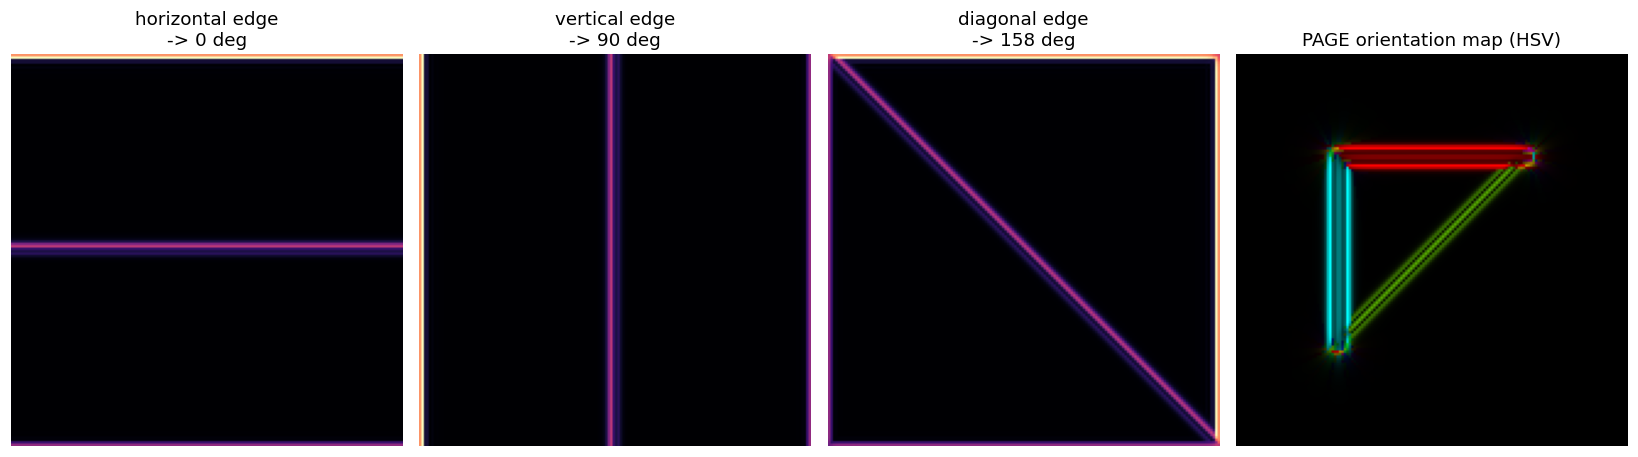

In [6]:
fig, ax = plt.subplots(1, 4, figsize=(15, 4))
for a, kind in zip(ax[:3], ("horizontal", "vertical", "diagonal")):
    r = page(make_edge(kind), orientations).max(axis=0)
    a.imshow(r, cmap="magma"); a.set_title(f"{kind} edge\n-> {dominant[kind]:.0f} deg"); a.axis("off")
ax[3].imshow(rgb); ax[3].set_title("PAGE orientation map (HSV)"); ax[3].axis("off")
plt.tight_layout(); plt.show()

## Summary

- **PAGE** replaces PST's single isotropic phase kernel with a **bank of oriented** kernels
  $\phi_r(\rho)D_k(\theta)$ -- the PST radial phase times an angular window -- so the phase response is
  **direction-selective**.
- A per-pixel argmax over orientation yields an **orientation-encoded edge map** (hue = direction); on
  single-orientation test edges the dominant bin correctly tracks the edge (horizontal 0 deg, vertical
  90 deg, diagonal in between).
- Structurally it is the same all-pass dispersive-phase operator as this project's $H_D(f)$, made
  anisotropic: a linear FFT filter bank plus an argmax. Companion notebooks: `phycv_phase_stretch_transform`
  (PST) and `phycv_vevid` (low-light enhancement).

Subject-verb-object: the angular window steers the phase kernel; each orientation lights its own edges; the
argmax reads the direction; the HSV map paints it.